In [1]:
print("Test")

Test


In [2]:
import os, os.path
import pandas as pd
import ast
import tqdm
import glob
import sys
import pathlib
import copy
import time
import random
import numpy as np


from scripts.DepChainTagger.config import SEED

random_seed = SEED
random.seed(SEED)
np.random.seed(SEED)

In [8]:
import estnltk
from estnltk.default_resolver import make_resolver
from estnltk.taggers import VabamorfAnalyzer
from estnltk_neural.taggers import StanzaSyntaxTagger
from estnltk.storage.postgres import PostgresStorage
from estnltk.taggers.miscellaneous.propbank.preannotator import PropBankPreannotator

In [59]:
from scripts.DepChainTagger import (
    ConditionMode,
    DepChainTagger,
    DepTaggerOrchestrator,
    DirectionMode,
    EdgeConstraint,
    NodeConstraint,
    PathPattern,
    ValueCondition,
    NestedValueCondition,
    SyntaxGraphIndex,
)

In [10]:
import importlib
import scripts.DepChainTagger

# Reload the module to ensure that the latest changes are reflected
importlib.reload(scripts.DepChainTagger)

<module 'scripts.DepChainTagger' from 'E:\\Git_projects\\EstNLTK\\EstNLTK_DependencyChains\\scripts\\DepChainTagger\\__init__.py'>

In [124]:
# Download the Stanza models for Estonian if not already present
stanza_syntax_tagger = StanzaSyntaxTagger(
    input_type="morph_extended",
    input_morph_layer="morph_extended",
    add_parent_and_children=True,
)
# estnltk.download("stanzasyntaxtagger")
# Initialize PropBankPreannotator working on 'stanza_syntax' layer
propbank_annotator = PropBankPreannotator(
    input_syntax_layer="stanza_syntax", add_arg_descriptions=True, add_arg_feats=True
)

In [125]:
# sample_text = "Ta andis lendurist abikaasale oma raamatu. See raamat on väga huvitav."
sample_text = "Üks ütles, et 1. mail tähistab palju maid töörahvapüha."
text_obj = estnltk.Text(sample_text)
text_obj.tag_layer("morph_extended")
# stanza_syntax_web_tagger.tag(text_obj)
stanza_syntax_tagger.tag(text_obj)
propbank_annotator.tag(text_obj)
display(text_obj)

Text(text='Üks ütles, et 1. mail tähistab palju maid töörahvapüha.')

## Testing on sample corpus


In [126]:
from collections.abc import Sequence
from typing import Any
import matplotlib.pyplot as plt
import numpy as np


def plot_depchain_performance(
    timings: Sequence[Any],
    step_size: int,
    ms_threshold_s: float = 5.0,
    title_prefix: str = "DepChainTagger Performance",
    figsize: tuple[float, float] = (14, 6),
) -> tuple[plt.Figure, np.ndarray]:
    """
    Plot DepChainTagger performance using step-wise timing groups.

    Parameters
    ----------
    timings
        Either:
        - a flat sequence of timing values, one value per step, or
        - a sequence of step groups, where each step group is a sequence of
          timing values. This supports ragged groups, so the last step may be
          shorter than the others.
    step_size
        Number of text objects processed per full step.
    ms_threshold_s
        If the largest step average is below this threshold, values are shown
        in milliseconds. Otherwise, seconds are used.
    title_prefix
        Plot title prefix.
    figsize
        Figure size.

    Returns
    -------
    (figure, axes)
        A Matplotlib figure and the axes array.

    Raises
    ------
    ValueError
        If timings is empty, contains empty step groups, or step_size is not
        positive.
    """
    if step_size <= 0:
        raise ValueError("step_size must be a positive integer.")

    timings_list = list(timings)
    if not timings_list:
        raise ValueError("timings must not be empty.")

    # Detect whether the input is:
    # 1) a flat list of scalars, or
    # 2) a list of step groups.
    first_item = timings_list[0]
    is_nested = isinstance(first_item, (list, tuple, np.ndarray))

    if is_nested:
        step_groups = [np.asarray(group, dtype=float) for group in timings_list]
        if any(group.size == 0 for group in step_groups):
            raise ValueError("timings must not contain empty step groups.")
        step_sizes = np.array([len(group) for group in step_groups], dtype=int)
        x_values = np.cumsum(step_sizes)
        flat_values_s = np.concatenate(step_groups)
    else:
        # Treat each scalar as one step measurement.
        step_groups = [np.asarray([value], dtype=float) for value in timings_list]
        x_values = np.arange(1, len(step_groups) + 1, dtype=int) * step_size
        flat_values_s = np.asarray(timings_list, dtype=float)

    step_mean_s = np.array([np.mean(group) for group in step_groups], dtype=float)
    step_min_s = np.array([np.min(group) for group in step_groups], dtype=float)
    step_max_s = np.array([np.max(group) for group in step_groups], dtype=float)
    cumulative_s = np.cumsum(step_mean_s)

    # Switch units based on the largest per-step average.
    use_ms = np.max(step_mean_s) < ms_threshold_s
    scale = 1000.0 if use_ms else 1.0
    unit = "ms" if use_ms else "s"

    step_mean = step_mean_s * scale
    step_min = step_min_s * scale
    step_max = step_max_s * scale
    cumulative = cumulative_s * scale
    flat_values = flat_values_s * scale

    fig, axes = plt.subplots(
        1,
        2,
        figsize=figsize,
        gridspec_kw={"width_ratios": [3, 1]},
    )

    # Step-wise line plot.
    ax = axes[0]
    ax.plot(x_values, step_mean, label="Average per step", linewidth=2)
    ax.plot(x_values, cumulative, label="Cumulative average time", linewidth=2)
    ax.plot(x_values, step_min, label="Minimum per step", linestyle="--", linewidth=1.5)
    ax.plot(x_values, step_max, label="Maximum per step", linestyle="--", linewidth=1.5)
    ax.fill_between(
        x_values,
        step_min,
        step_max,
        alpha=0.2,
        label="Min-max range",
    )

    ax.set_title(f"{title_prefix} - Step-wise")
    ax.set_xlabel("Number of text objects processed")
    ax.set_ylabel(f"Time ({unit})")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

    # Overall distribution box plot.
    ax_box = axes[1]
    ax_box.boxplot(
        flat_values,
        vert=True,
        patch_artist=True,
        showfliers=True,
        boxprops={"alpha": 0.5},
        medianprops={"linewidth": 2},
    )
    ax_box.set_title(f"{title_prefix} - Distribution")
    ax_box.set_xlabel("All timings")
    ax_box.set_ylabel(f"Time ({unit})")
    ax_box.set_xticks([1])
    ax_box.set_xticklabels(["Timings"])
    ax_box.grid(True, axis="y", linestyle=":", alpha=0.6)

    fig.tight_layout()
    return fig, axes

In [114]:
pgpass_file = "./pgpass.txt"
assert os.path.exists(pgpass_file)

storage = PostgresStorage(
    pgpass_file=pgpass_file,
    schema="estonian_text_corpora",
    role="estonian_text_corpora_read",
)

INFO:storage.py:57: connecting to host: 'postgres.keeleressursid.ee', port: '5432', dbname: 'estonian-text-corpora', user: 'sandersa'
INFO:storage.py:108: schema: 'estonian_text_corpora', temporary: False, role: 'estonian_text_corpora_read'


In [115]:
display(storage.collections)

['koondkorpus_base_subset_of_5000_v2',
 'koondkorpus_base_v2',
 'koondkorpus_sentences',
 'koondkorpus_sentences_test_5000_sg_thread',
 'koondkorpus_syntax_subset',
 'koondkorpus_words_v16_1']

In [116]:
# Test collection
collection = storage["koondkorpus_sentences_test_5000_sg_thread"]
display(collection)

In [97]:
# Define a simple pattern to test the matcher
pattern = PathPattern(
    name="noun_st_noun",
    node_steps=(
        NodeConstraint(
            role="S_el",
            attribute_conditions={
                "upostag": ValueCondition(mode=ConditionMode.EXACT, value="S")
            },
            nested_attribute_conditions={
                "feats": NestedValueCondition(
                    mode=ConditionMode.EXACT, required={"sg": "sg", "el": "el"}
                )
            },
        ),
        NodeConstraint(
            role="S",
            attribute_conditions={
                "upostag": ValueCondition(mode=ConditionMode.EXACT, value="S")
            },
        ),
    ),
    edge_steps=(
        EdgeConstraint(
            direction=DirectionMode.UP,
            attribute_conditions={
                "deprel": ValueCondition(mode=ConditionMode.REGEX, value=".*mod.*")
            },
            min_hops=1,
            max_hops=3,
        ),
    ),
)

In [98]:
dc_tagger = DepChainTagger(
    patterns=(pattern,), syntax_layer="stanza_syntax", sentences_layer="sentences"
)

In [99]:
test_text_obj = estnltk.Text("Lendurist abikaasa andis oma raamatu.")
test_text_obj.tag_layer("morph_extended")
stanza_syntax_tagger.tag(test_text_obj)
dc_tagger.tag(test_text_obj)
display(test_text_obj["stanza_syntax"])
display(test_text_obj["dep_chains"])

Layer(name='stanza_syntax', attributes=('id', 'lemma', 'upostag', 'xpostag', 'feats', 'head', 'deprel', 'deps', 'misc', 'parent_span', 'children'), spans=SL[Span('Lendurist', [{'id': 1, 'lemma': 'lendur', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'com': 'com', 'sg': 'sg', 'el': 'el'}), 'head': 2, 'deprel': 'nmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('abikaasa', [{'id': 2, 'lemma': 'abikaasa', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'com': 'com', 'sg': 'sg', 'nom': 'nom'}), 'head': 3, 'deprel': 'nsubj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('andis', [{'id': 3, 'lemma': 'andma', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'aux': 'aux', 'indic': 'indic', 'impf': 'impf', 'ps3': 'ps3', 'sg': 'sg', 'ps': 'ps', 'af': 'af'}), 'head': 0, 'deprel': 'root', 'deps': '_', 'misc': '_', 'parent_span': None, 'children': <class 'tuple'>}]),
Span('oma', [{'id': 4, 'lemma': 'oma', 'upostag': 'P', 'xpostag': 'P', 'feats': OrderedDict({'sg': 'sg', 'gen': 'gen'}), 'head': 5, 'deprel': 'nmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('raamatu', [{'id': 5, 'lemma': 'raamat', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'com': 'com', 'sg': 'sg', 'gen': 'gen'}), 'head': 3, 'deprel': 'obl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': <class 'tuple'>}]),
Span('.', [{'id': 6, 'lemma': '.', 'upostag': 'Z', 'xpostag': 'Z', 'feats': OrderedDict(), 'head': 3, 'deprel': 'punct', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}])])

RelationLayer(name='dep_chains', span_names=('S_el', 'S'), attributes=('pattern_name', 'matched_text'), relations=[Relation([NamedSpan(S_el: 'Lendurist'), NamedSpan(S: 'abikaasa')], [{'pattern_name': 'noun_st_noun', 'matched_text': 'Lendurist abikaasa'}])])

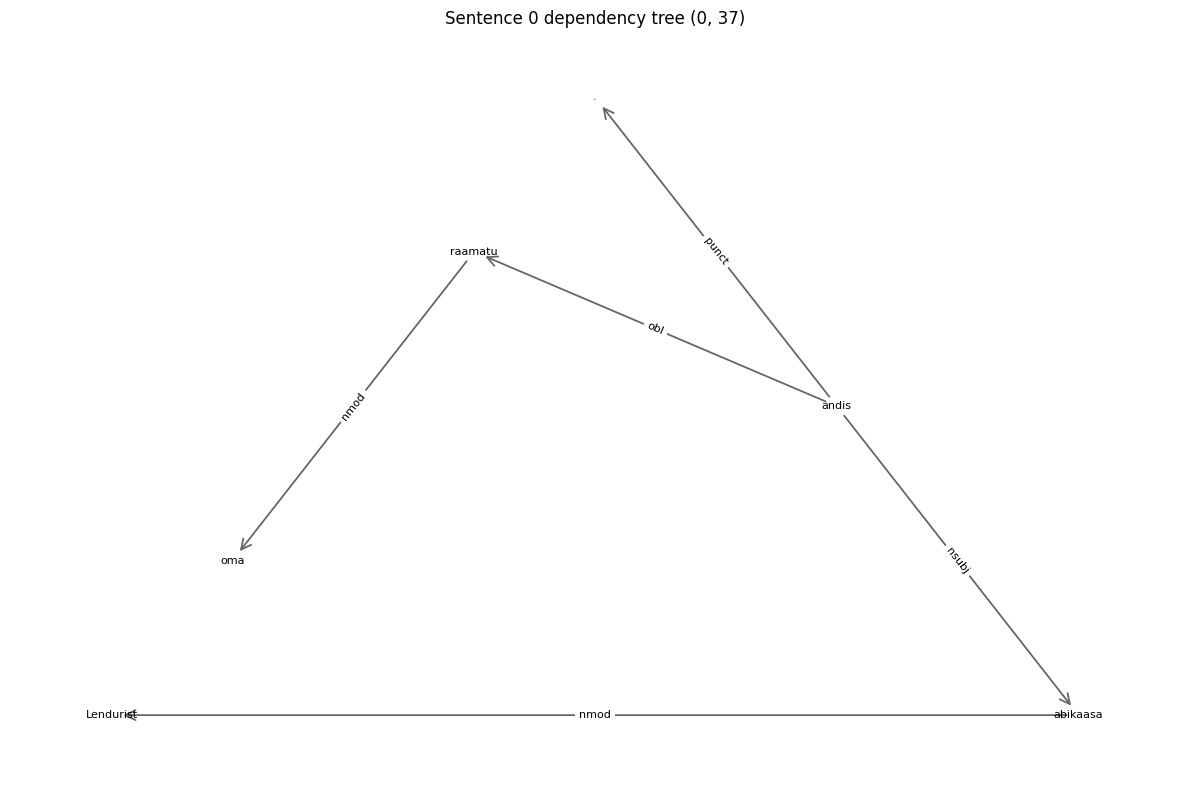

In [111]:
graph_index = SyntaxGraphIndex(
    stanza_syntax_layer=test_text_obj["stanza_syntax"],
    sentence_id=0,
    sentence_span=(
        test_text_obj["sentences"][0].start,
        test_text_obj["sentences"][0].end,
    ),
)

SyntaxGraphIndex.visualize(
    graph_index,
    layout="planar",
    node_size=0,
    show=False,
)

In [112]:
dc_tagger = DepChainTagger(
    patterns=(pattern,),
    syntax_layer="v172_stanza_syntax",
    sentences_layer="sentences",
    include_pattern_constraints=False,
)

In [ ]:
timings = {}
match_count = 0
for text_id, text_obj in tqdm.tqdm(
    collection.select(layers=["sentences", "v172_stanza_syntax"])
):
    if len(text_obj["v172_stanza_syntax"]) > 0:
        # display(text_obj)
        text_obj_test = copy.deepcopy(
            text_obj
        )  # Create a copy of the text object to avoid modifying the original
        t0 = time.perf_counter()
        dc_tagger.tag(text_obj_test)
        t1 = time.perf_counter()
        timings[text_id] = t1 - t0
        if len(text_obj_test["dep_chains"]) > 0:
            match_count += 1
            # print(f"Text ID: {text_id}")
            # display(text_obj_test["dep_chains"])

100%|██████████| 159745/159745 [13:43<00:00, 194.08it/s]

Total texts processed: 159745
Total matches found: 2690
Total tagging time: 23.68 seconds
Average tagging time per text: 0.15 milliseconds
Maximum tagging time for a single text: 167.21 milliseconds
Minimum tagging time for a single text: 0.03 milliseconds


In [ ]:
timings_file = "depchain_tagger_timings.csv"

In [ ]:
# Save timings to a file for later analysis
timings_df = pd.DataFrame(list(timings.items()), columns=["text_id", "tagging_time_s"])
timings_df.to_csv(timings_file, index=False)

In [128]:
timings_df = pd.read_csv(timings_file)
timings = timings_df.set_index("text_id")["tagging_time_s"].to_dict()

In [131]:
print(f"Total texts processed: {len(timings)}")
print(f"Total matches found: {match_count}")

# Calculate and display tagging times
total_time = sum(timings.values())
if total_time > 1:
    print(f"Total tagging time: {total_time:.2f} seconds")
else:
    print(f"Total tagging time: {total_time * 1000:.2f} milliseconds")

average_time = sum(timings.values()) / len(timings) if timings else 0
if average_time > 1:
    print(f"Average tagging time per text: {average_time:.2f} seconds")
else:
    print(f"Average tagging time per text: {average_time * 1000:.2f} milliseconds")

max_time = max(timings.values()) if timings else 0
if max_time > 1:
    print(f"Maximum tagging time for a single text: {max_time:.2f} seconds")
else:
    print(f"Maximum tagging time for a single text: {max_time * 1000:.2f} milliseconds")

min_time = min(timings.values()) if timings else 0
if min_time > 1:
    print(f"Minimum tagging time for a single text: {min_time:.2f} seconds")
else:
    print(f"Minimum tagging time for a single text: {min_time * 1000:.2f} milliseconds")

Total texts processed: 159745
Total matches found: 2690
Total tagging time: 23.68 seconds
Average tagging time per text: 0.15 milliseconds
Maximum tagging time for a single text: 167.21 milliseconds
Minimum tagging time for a single text: 0.03 milliseconds


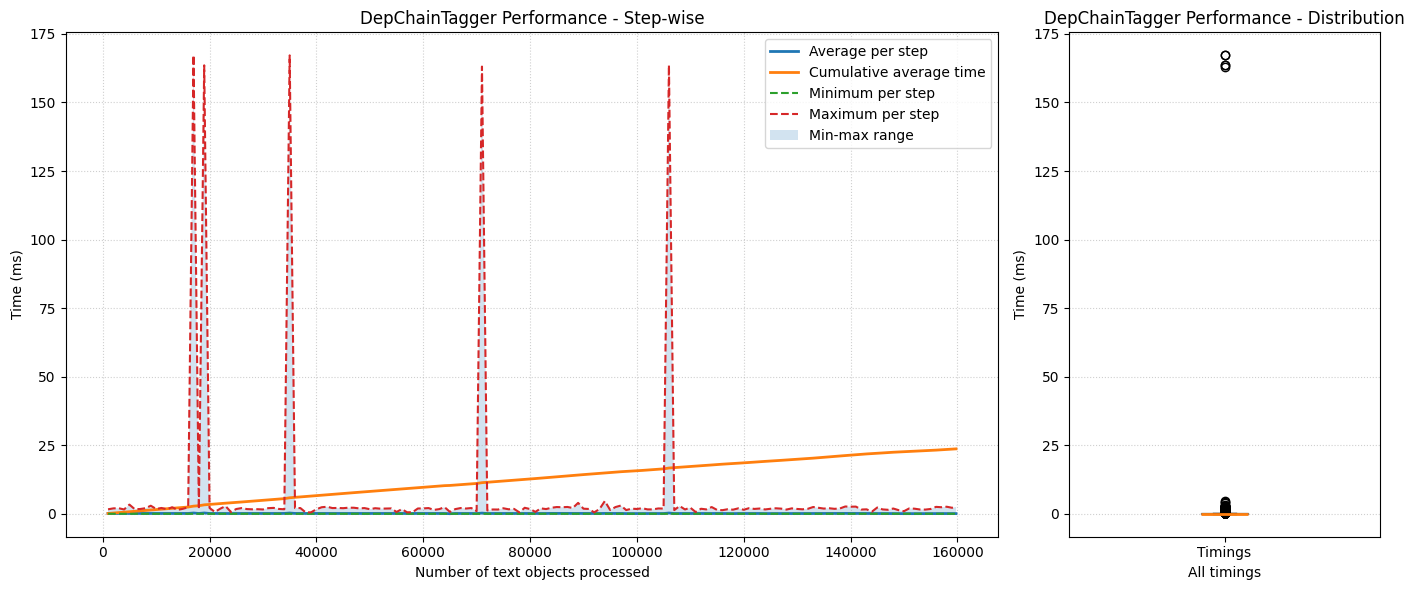

In [129]:
# Split timings into steps based on step_size
step_size = 1000  # Example step size (number of texts per step)
timing_values = list(timings.values())
steps = [
    timing_values[i : i + step_size] for i in range(0, len(timing_values), step_size)
]
fig, axes = plot_depchain_performance(
    timings=steps,
    step_size=step_size,
    ms_threshold_s=5.0,
    title_prefix="DepChainTagger Performance",
    figsize=(14, 6),
)
plt.show()

In [113]:
# Close the storage connection after testing
storage.close()

### Testing on pre-annotation of PropBank semantic roles


In [188]:
# Define a simple pattern to test the matcher
pattern = PathPattern(
    name="who_V_to/what",
    node_steps=(
        NodeConstraint(
            role="who",
        ),
        NodeConstraint(
            role="V",
            attribute_conditions={
                "upostag": ValueCondition(mode=ConditionMode.EXACT, value="V")
            },
        ),
        NodeConstraint(
            role="to_or_what",
        ),
    ),
    edge_steps=(
        EdgeConstraint(
            direction=DirectionMode.UP,
            attribute_conditions={
                "deprel": ValueCondition(mode=ConditionMode.REGEX, value=".*nsubj.*")
            },
            min_hops=1,
            max_hops=1,
        ),
        EdgeConstraint(
            direction=DirectionMode.DOWN,
            attribute_conditions={
                "deprel": ValueCondition(mode=ConditionMode.REGEX, value=".*obl.*")
            },
            min_hops=1,
            max_hops=1,
        ),
    ),
)

In [189]:
dc_tagger = DepChainTagger(
    patterns=(pattern,), syntax_layer="stanza_syntax", sentences_layer="sentences"
)

In [190]:
test_text_obj = estnltk.Text(
    "Ants rääkis asjast Arvole. Seega, ta edastas sõnumi edukalt adressaadile. Küsisin IT-juhilt abi."
)
test_text_obj.tag_layer("morph_extended")
stanza_syntax_tagger.tag(test_text_obj)
propbank_annotator.tag(test_text_obj)
dc_tagger.tag(test_text_obj)
# display(test_text_obj)
display(test_text_obj["stanza_syntax"])
display(test_text_obj["pre_semantic_roles"])
display(test_text_obj["dep_chains"])

Layer(name='stanza_syntax', attributes=('id', 'lemma', 'upostag', 'xpostag', 'feats', 'head', 'deprel', 'deps', 'misc', 'parent_span', 'children'), spans=SL[Span('Ants', [{'id': 1, 'lemma': 'Ants', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'prop': 'prop', 'sg': 'sg', 'nom': 'nom'}), 'head': 2, 'deprel': 'nsubj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('rääkis', [{'id': 2, 'lemma': 'rääkima', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'aux': 'aux', 'indic': 'indic', 'impf': 'impf', 'ps3': 'ps3', 'sg': 'sg', 'ps': 'ps', 'af': 'af'}), 'head': 0, 'deprel': 'root', 'deps': '_', 'misc': '_', 'parent_span': None, 'children': <class 'tuple'>}]),
Span('asjast', [{'id': 3, 'lemma': 'asi', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'com': 'com', 'sg': 'sg', 'el': 'el'}), 'head': 2, 'deprel': 'obl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('Arvole', [{'id': 4, 'lemma': 'Arvo', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'prop': 'prop', 'sg': 'sg', 'all': 'all'}), 'head': 2, 'deprel': 'obl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('.', [{'id': 5, 'lemma': '.', 'upostag': 'Z', 'xpostag': 'Z', 'feats': OrderedDict(), 'head': 2, 'deprel': 'punct', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('Seega', [{'id': 1, 'lemma': 'seega', 'upostag': 'D', 'xpostag': 'D', 'feats': OrderedDict(), 'head': 4, 'deprel': 'advmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span(',', [{'id': 2, 'lemma': ',', 'upostag': 'Z', 'xpostag': 'Z', 'feats': OrderedDict(), 'head': 4, 'deprel': 'punct', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('ta', [{'id': 3, 'lemma': 'tema', 'upostag': 'P', 'xpostag': 'P', 'feats': OrderedDict({'sg': 'sg', 'nom': 'nom'}), 'head': 4, 'deprel': 'nsubj', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('edastas', [{'id': 4, 'lemma': 'edastama', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'main': 'main', 'indic': 'indic', 'impf': 'impf', 'ps3': 'ps3', 'sg': 'sg', 'ps': 'ps', 'af': 'af'}), 'head': 0, 'deprel': 'root', 'deps': '_', 'misc': '_', 'parent_span': None, 'children': <class 'tuple'>}]),
Span('sõnumi', [{'id': 5, 'lemma': 'sõnum', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'com': 'com', 'sg': 'sg', 'gen': 'gen'}), 'head': 4, 'deprel': 'obl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('edukalt', [{'id': 6, 'lemma': 'edukalt', 'upostag': 'D', 'xpostag': 'D', 'feats': OrderedDict(), 'head': 4, 'deprel': 'advmod', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('adressaadile', [{'id': 7, 'lemma': 'adressaat', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'com': 'com', 'sg': 'sg', 'all': 'all'}), 'head': 4, 'deprel': 'obl', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('.', [{'id': 8, 'lemma': '.', 'upostag': 'Z', 'xpostag': 'Z', 'feats': OrderedDict(), 'head': 4, 'deprel': 'punct', 'deps': '_', 'misc': '_', 'parent_span': <class 'estnltk_core.layer.span.Span'>, 'children': ()}]),
Span('Küsisin', [{'id': 1, 'lemma': 'küsima', 'upostag': 'V', 'xpostag': 'V', 'feats': OrderedDict({'mod': 'mod', 'indic': 'indic', 'impf': 'impf', 'ps1': 'ps1', 'sg': 'sg', 'ps': 'ps', 'af': 'af'}), 'head': 0, 'deprel': 'root', 'deps': '_', 'misc': '_', 'parent_span': None, 'children': <class 'tuple'>}]),
Span('IT-juhilt', [{'id': 2, 'lemma': 'IT-juht', 'upostag': 'S', 'xpostag': 'S', 'feats': OrderedDict({'com': 'com', 'sg': 'sg', 'abl': 'abl'}), 'head': 1, 'deprel': 'obl', 'deps': '_', 'mi

RelationLayer(name='pre_semantic_roles', span_names=('verb', 'arg0', 'arg1', 'arg2', 'arg3', 'arg4', 'arg5', 'argm_mnr', 'argm_tmp', 'argm_loc'), attributes=('sense_id', 'arg0_desc', 'arg1_desc', 'arg2_desc', 'arg3_desc', 'arg4_desc', 'arg5_desc', 'arg0_feats', 'arg1_feats', 'arg2_feats', 'arg3_feats', 'arg4_feats', 'arg5_feats', 'argm_mnr_feats', 'argm_tmp_feats', 'argm_loc_feats'), relations=[Relation([NamedSpan(verb: ['rääkis']), NamedSpan(arg0: ['Ants']), NamedSpan(arg2: ['Arvole']), NamedSpan(arg3: ['asjast'])], [{'sense_id': 'rääkima_1', 'arg0_desc': 'rääkija', 'arg1_desc': None, 'arg2_desc': 'adressaat: kellele/kellega', 'arg3_desc': 'millegi kohta/millest', 'arg4_desc': None, 'arg5_desc': None, 'arg0_feats': ['deprel=nsubj'], 'arg1_feats': None, 'arg2_feats': ['deprel=obl', 'case=All'], 'arg3_feats': ['deprel=obl', 'case=Ela'], 'arg4_feats': None, 'arg5_feats': None, 'argm_mnr_feats': None, 'argm_tmp_feats': None, 'argm_loc_feats': None}]), Relation([NamedSpan(verb: ['edastas']), NamedSpan(arg0: ['ta']), NamedSpan(arg2: ['adressaadile'])], [{'sense_id': 'edastama_1', 'arg0_desc': 'edastaja', 'arg1_desc': None, 'arg2_desc': 'adressaat', 'arg3_desc': None, 'arg4_desc': None, 'arg5_desc': None, 'arg0_feats': ['deprel=nsubj'], 'arg1_feats': None, 'arg2_feats': ['deprel=obl', 'case=All'], 'arg3_feats': None, 'arg4_feats': None, 'arg5_feats': None, 'argm_mnr_feats': None, 'argm_tmp_feats': None, 'argm_loc_feats': None}]), Relation([NamedSpan(verb: ['Küsisin']), NamedSpan(arg1: ['abi']), NamedSpan(arg2: ['IT-juhilt'])], [{'sense_id': 'küsima_1', 'arg0_desc': None, 'arg1_desc': 'mida/et', 'arg2_desc': 'kelleltki/kellegi käest', 'arg3_desc': None, 'arg4_desc': None, 'arg5_desc': None, 'arg0_feats': None, 'arg1_feats': ['deprel=obj'], 'arg2_feats': ['deprel=obl', 'case=Abl'], 'arg3_feats': None, 'arg4_feats': None, 'arg5_feats': None, 'argm_mnr_feats': None, 'argm_tmp_feats': None, 'argm_loc_feats': None}])])

layer name,span_names,attributes,enveloping,ambiguous,relation count
dep_chains,"who, V, to_or_what","pattern_name, matched_text",None,True,4
,who,V,to_or_what,pattern_name,matched_text
0,Ants,rääkis,asjast,who_V_to/what,Ants rääkis asjast
1,Ants,rääkis,Arvole,who_V_to/what,Ants rääkis Arvole
2,ta,edastas,sõnumi,who_V_to/what,ta edastas sõnumi
3,ta,edastas,adressaadile,who_V_to/what,ta edastas adressaadile


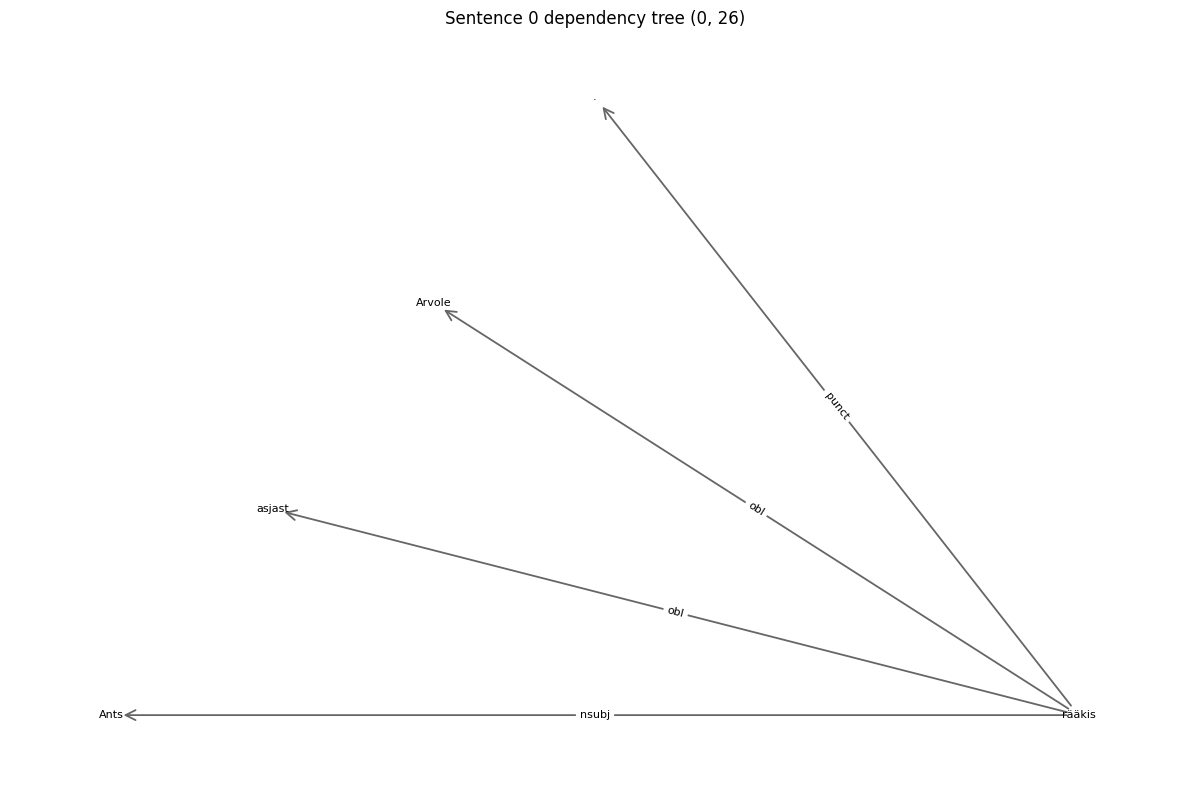

In [174]:
graph_index = SyntaxGraphIndex(
    stanza_syntax_layer=test_text_obj["stanza_syntax"][0:5],
    sentence_id=0,
    sentence_span=(
        test_text_obj["sentences"][0].start,
        test_text_obj["sentences"][0].end,
    ),
)

SyntaxGraphIndex.visualize(
    graph_index,
    layout="planar",
    node_size=0,
    show=False,
)

In [ ]:
dc_tagger = DepChainTagger(
    patterns=(pattern,),
    syntax_layer="v172_stanza_syntax",
    sentences_layer="sentences",
    include_pattern_constraints=False,
)

In [ ]:
timings = {}
match_count = 0
for text_id, text_obj in tqdm.tqdm(
    collection.select(layers=["sentences", "v172_stanza_syntax"]).head(10)
):
    if len(text_obj["v172_stanza_syntax"]) > 0:
        # display(text_obj)
        text_obj_test = copy.deepcopy(
            text_obj
        )  # Create a copy of the text object to avoid modifying the original
        t0 = time.perf_counter()
        dc_tagger.tag(text_obj_test)
        t1 = time.perf_counter()
        timings[text_id] = t1 - t0
        if len(text_obj_test["dep_chains"]) > 0:
            match_count += 1
            # print(f"Text ID: {text_id}")
            # display(text_obj_test["dep_chains"])

100%|██████████| 159745/159745 [13:43<00:00, 194.08it/s]

Total texts processed: 159745
Total matches found: 2690
Total tagging time: 23.68 seconds
Average tagging time per text: 0.15 milliseconds
Maximum tagging time for a single text: 167.21 milliseconds
Minimum tagging time for a single text: 0.03 milliseconds


In [175]:
# Close the storage connection after testing
storage.close()